In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad
import seaborn as sns
import time

### Parámetros del sistema y configuración de simulación

In [ ]:
# Tank cross-sectional areas [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Outlet orifice areas [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Pump flow constants [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Flow division parameters between upper and lower tanks
gamma1, gamma2 = 0.70, 0.60

# Constant gravitational acceleration [cm/s^2]
g = 981.0

# Time configuration and integration step
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Initial conditions for the levels of the four tanks [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Standard deviation of Gaussian noise for inputs and outputs
noise_input_std = 0.1
noise_output_std = 0.1

# Duration of steps for the excitation signal
t_change_min = 50
t_change_max = 50

# Voltage operating limits for the water pumps
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

In [ ]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Unpack levels for the four tanks
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Numerical protection to avoid square roots of negative values
    h_safe = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_safe

    # Get input voltages at time t
    v1, v2 = u_func(t)

    # Mass balance for lower tanks with inflow from upper tanks
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Mass balance for upper tanks fed by divided flow
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Return state derivatives for the integrator
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [ ]:
# Random number generator configuration with a fixed seed
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Initialization of indexes for signal level changes
t_change_indexes = []
curr_idx = 0

# Generation of random duration intervals for the steps
while curr_idx < n:
    t_change_indexes.append(curr_idx)

    # Calculation of step duration in seconds and its equivalent in steps
    duration_seg = rng_stream.uniform(t_change_min, t_change_max)
    step_sequences = int(duration_seg / dt)
    curr_idx += step_sequences

# Generation of random amplitudes for the voltages of both pumps
steps_values = rng_stream.uniform(V_min, V_max, size=(len(t_change_indexes), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [ ]:
# Initialization of the matrix for the ideal input signal (no noise)
u_ideal = np.zeros((n, 2))

# Construction of the piecewise constant signal based on change indexes
for i in range(len(t_change_indexes)):
    idx_start = t_change_indexes[i]

    # Definition of the upper limit for the current interval
    if i == len(t_change_indexes) - 1:
        idx_end = n
    else:
        idx_end = t_change_indexes[i+1]

    # Assignment of voltages v1 and v2 for the defined time segment
    u_ideal[idx_start:idx_end, :] = steps_values[i]

# Generation of Gaussian white noise to simulate actuator uncertainty
noise_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Application of noise and clipping the signal to physical operating limits
u_noisy = u_ideal + noise_input
u_noisy = np.clip(u_noisy, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [ ]:
# Creation of interpolation function for the noisy input
u_fun = interp1d(t, u_noisy, axis=0, kind='linear', fill_value='extrapolate')

# Definition of the wrapper to integrate the model with fixed parameters
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Solving the system of differential equations using RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extraction and organization of the simulated level trajectories
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [ ]:
# Generation of Gaussian white noise for the sensors of the four tanks
noise_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
noise_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
noise_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
noise_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Application of noise to simulated levels with lower physical limit restriction
h1_noisy = np.maximum(h1_sim + noise_h1, 0.0)
h2_noisy = np.maximum(h2_sim + noise_h2, 0.0)
h3_noisy = np.maximum(h3_sim + noise_h3, 0.0)
h4_noisy = np.maximum(h4_sim + noise_h4, 0.0)

# Consolidation of time vectors, noisy inputs, and measured levels
t_full = t_out
u_full = u_noisy
h1_full = h1_noisy
h2_full = h2_noisy
h3_full = h3_noisy
h4_full = h4_noisy

# Definition of the total dimension for the training dataset
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

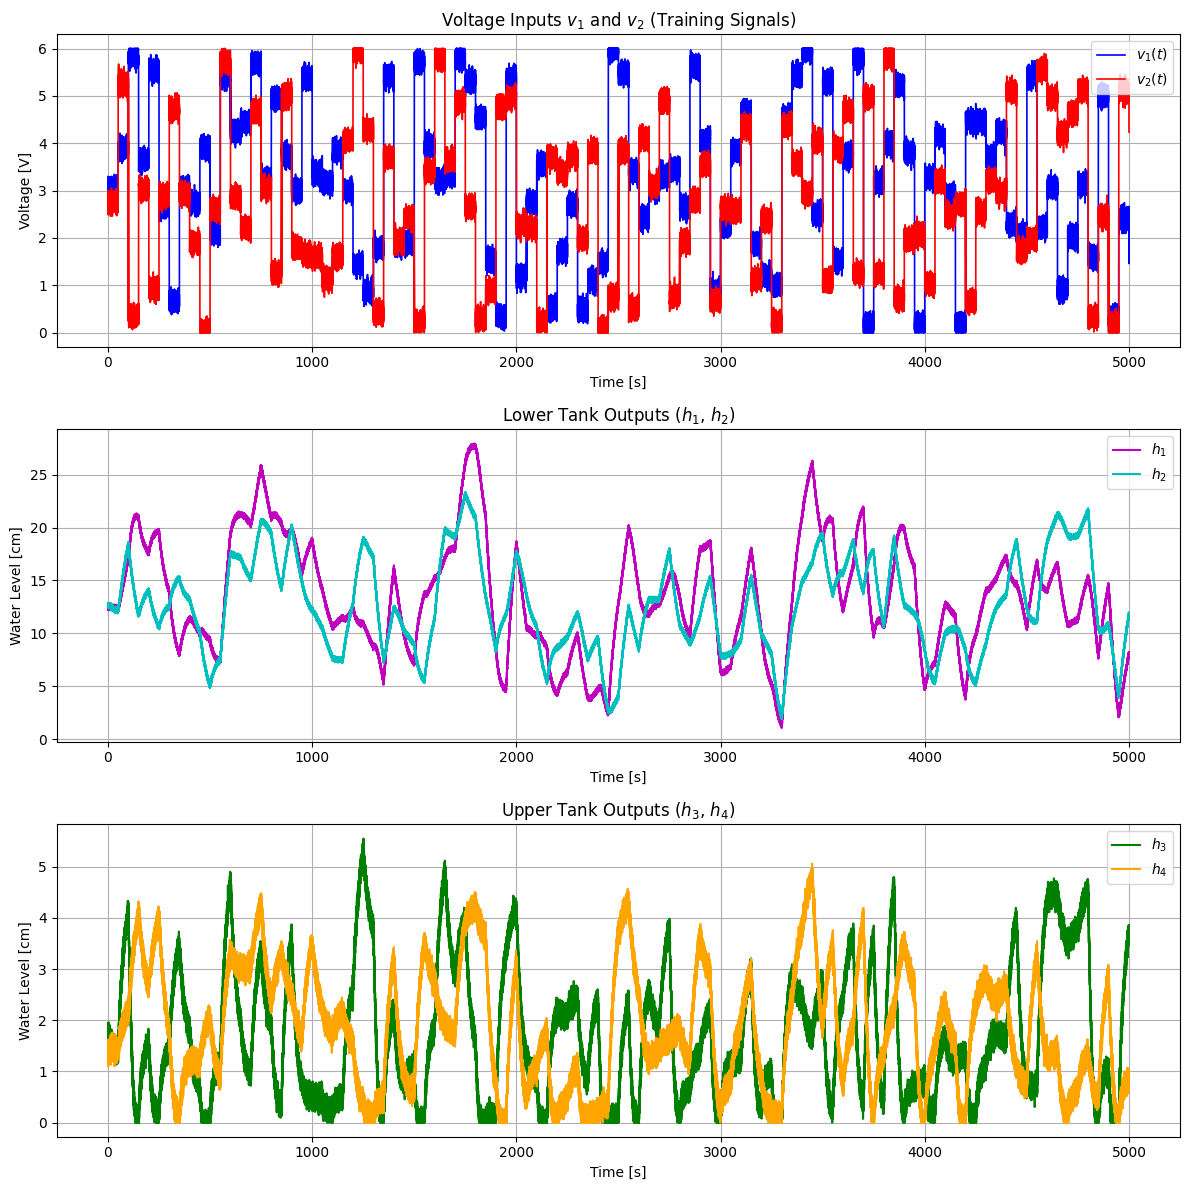

In [ ]:
# Figure for visualizing the input and output signals of the system
plt.figure(figsize=(12, 12))

# Subplot 1: Control input signals (Pump voltages v1 and v2)
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title('Voltage Inputs $v_1$ and $v_2$ (Training Signals)')
plt.legend(loc='upper right')
plt.grid(True)

# Subplot 2: Lower tank levels (h1 and h2)
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Lower Tank Outputs ($h_1$, $h_2$)')
plt.legend(loc='upper right')
plt.grid(True)

# Subplot 3: Upper tank levels (h3 and h4)
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Upper Tank Outputs ($h_3$, $h_4$)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Level estimation
    P = np.zeros(n)          # Error covariance
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Prediction
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q

        # Update
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus

    return x_hat

# Application with tuning parameters (Q: process, R: sensor)
h1_full = kalman_filter(h1_full)
h2_full = kalman_filter(h2_full)
h3_full = kalman_filter(h3_full)
h4_full = kalman_filter(h4_full)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

## Preprocesamiento, normalización y división de datos

In [ ]:
# Inputs: Using original raw data (non-smoothed) for state and control signals
X_train = np.hstack([
    h1_full[:-1, None],
    h2_full[:-1, None],
    h3_full[:-1, None],
    h4_full[:-1, None],
    u_full[:-1, :]
])

# Outputs: Original next state used for training the transition model
Y_train = np.hstack([
    h1_full[1:, None],
    h2_full[1:, None],
    h3_full[1:, None],
    h4_full[1:, None]
])

## Arquitectura de red neuronal para entrenamiento

In [ ]:
# MIMO system dimensions
INPUT_SIZE = 6   # [h1(k), h2(k), h3(k), h4(k), v1(k), v2(k)]
OUTPUT_SIZE = 4  # [h1(k+1), h2(k+1), h3(k+1), h4(k+1)]
HIDDEN_LAYERS = 4
HIDDEN_NEURONS = 48

class PINN_StateSpace_SiLU(nn.Module):
    def __init__(self, input_size, output_size, num_layers, num_neurons):
        super(PINN_StateSpace_SiLU, self).__init__()

        layers = []

        # Input layer: Processes states and controls simultaneously
        layers.append(nn.Linear(input_size, num_neurons))
        layers.append(nn.SiLU())

        # Hidden layers: Capture coupling between the 4 tanks
        for _ in range(num_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.SiLU())

        # Output layer: Predicts the 4 states at k+1
        layers.append(nn.Linear(num_neurons, output_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Determine the computing device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model instance adapted for the 4-tank system
model = PINN_StateSpace_SiLU(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_LAYERS, HIDDEN_NEURONS).to(device)

print(f"MIMO PINN Model (4 Tanks) created. Inputs: {INPUT_SIZE}, Outputs: {OUTPUT_SIZE}")
print(f"Current device: {device}")

MIMO PINN Model (4 Tanks) created. Inputs: 6, Outputs: 4
Current device: cuda


## Funciones de normalización y denormalización

In [ ]:
# Min-Max normalization to scale data between 0 and 1
def normalize_data(data, data_min, data_max):
    denom = data_max - data_min
    if denom == 0:
        return data
    return (data - data_min) / denom

# Inverse denormalization to restore data to its original physical units
def denormalize_data(data_norm, data_min, data_max):
    return data_norm * (data_max - data_min) + data_min

## Parámetros de escala para entrenamiento

In [ ]:
# Dictionary structure to store the Min/Max limits for each variable
SCALING_PARAMS = {}

# Scaling parameters for control inputs (v1 and v2) from u_full
v1_min, v1_max = X_train[:, 4].min(), X_train[:, 4].max()
v2_min, v2_max = X_train[:, 5].min(), X_train[:, 5].max()

SCALING_PARAMS['v1'] = {'min': v1_min, 'max': v1_max}
SCALING_PARAMS['v2'] = {'min': v2_min, 'max': v2_max}

# Scaling parameters for Tank 1 levels
h1_min = min(X_train[:, 0].min(), Y_train[:, 0].min())
h1_max = max(X_train[:, 0].max(), Y_train[:, 0].max())
SCALING_PARAMS['h1'] = {'min': h1_min, 'max': h1_max}

# Scaling parameters for Tank 2 levels
h2_min = min(X_train[:, 1].min(), Y_train[:, 1].min())
h2_max = max(X_train[:, 1].max(), Y_train[:, 1].max())
SCALING_PARAMS['h2'] = {'min': h2_min, 'max': h2_max}

# Scaling parameters for Tank 3 levels
h3_min = min(X_train[:, 2].min(), Y_train[:, 2].min())
h3_max = max(X_train[:, 2].max(), Y_train[:, 2].max())
SCALING_PARAMS['h3'] = {'min': h3_min, 'max': h3_max}

# Scaling parameters for Tank 4 levels
h4_min = min(X_train[:, 3].min(), Y_train[:, 3].min())
h4_max = max(X_train[:, 3].max(), Y_train[:, 3].max())
SCALING_PARAMS['h4'] = {'min': h4_min, 'max': h4_max}

print("Scaling parameters defined for the MIMO model [h1, h2, h3, h4, v1, v2].")

Scaling parameters defined for the MIMO model [h1, h2, h3, h4, v1, v2].


## Normalización de datos de entrada y salida para entrenamiento

In [ ]:
# Decomposition of X_train into current state and control inputs
h1_k = X_train[:, 0]
h2_k = X_train[:, 1]
h3_k = X_train[:, 2]
h4_k = X_train[:, 3]
v1_k = X_train[:, 4]
v2_k = X_train[:, 5]

# Decomposition of Y_train into target next states
h1_next = Y_train[:, 0]
h2_next = Y_train[:, 1]
h3_next = Y_train[:, 2]
h4_next = Y_train[:, 3]

# Min-Max normalization applied to each individual input variable
h1_k_norm = normalize_data(h1_k, SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_k_norm = normalize_data(h2_k, SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_k_norm = normalize_data(h3_k, SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_k_norm = normalize_data(h4_k, SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])
v1_k_norm = normalize_data(v1_k, SCALING_PARAMS['v1']['min'], SCALING_PARAMS['v1']['max'])
v2_k_norm = normalize_data(v2_k, SCALING_PARAMS['v2']['min'], SCALING_PARAMS['v2']['max'])

# Min-Max normalization applied to each individual output variable
h1_next_norm = normalize_data(h1_next, SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_next_norm = normalize_data(h2_next, SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_next_norm = normalize_data(h3_next, SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_next_norm = normalize_data(h4_next, SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Reassembly of normalized datasets for MIMO neural network training
X_train_norm = np.hstack([
    h1_k_norm[:, None],
    h2_k_norm[:, None],
    h3_k_norm[:, None],
    h4_k_norm[:, None],
    v1_k_norm[:, None],
    v2_k_norm[:, None]
])

Y_train_norm = np.hstack([
    h1_next_norm[:, None],
    h2_next_norm[:, None],
    h3_next_norm[:, None],
    h4_next_norm[:, None]
])

print("Normalization successfully applied to the 4-tank MIMO structure.")
print(f"Final dimensions: X_train_norm {X_train_norm.shape}, Y_train_norm {Y_train_norm.shape}")

Normalization successfully applied to the 4-tank MIMO structure.
Final dimensions: X_train_norm (100000, 6), Y_train_norm (100000, 4)


## Tensores de entrenamiento

In [ ]:
# Training Tensors for Data Loss
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train_norm, dtype=torch.float32).to(device)

# Physics tensor with gradient tracking for ODE residual evaluation
X_physics_tensor = X_train_tensor.clone().detach().requires_grad_(True)

print(f"\nPyTorch tensor conversion completed on device: {device}")
print(f"X_train_tensor.shape (Data Loss - MIMO 6): {X_train_tensor.shape}")
print(f"Y_train_tensor.shape (Data Loss - MIMO 4): {Y_train_tensor.shape}")
print(f"X_physics_tensor.shape (Physics Loss - MIMO 6): {X_physics_tensor.shape}")


PyTorch tensor conversion completed on device: cuda
X_train_tensor.shape (Data Loss - MIMO 6): torch.Size([100000, 6])
Y_train_tensor.shape (Data Loss - MIMO 4): torch.Size([100000, 4])
X_physics_tensor.shape (Physics Loss - MIMO 6): torch.Size([100000, 6])


## Función de pérdida física para la red neuronal informada por físicas

In [ ]:
class PhysicsLoss(nn.Module):
    def __init__(self, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2, epsilon, dt, SCALING_PARAMS):
        # Calculation of residuals for the 4-tank system: transition k -> k+1
        super(PhysicsLoss, self).__init__()

        # Store physical constants as tensors
        self.A1, self.A2 = torch.tensor(A1).to(device), torch.tensor(A2).to(device)
        self.A3, self.A4 = torch.tensor(A3).to(device), torch.tensor(A4).to(device)
        self.a1, self.a2 = torch.tensor(a1).to(device), torch.tensor(a2).to(device)
        self.a3, self.a4 = torch.tensor(a3).to(device), torch.tensor(a4).to(device)
        self.g = torch.tensor(g).to(device)
        self.k1, self.k2 = torch.tensor(k1).to(device), torch.tensor(k2).to(device)
        self.gamma1 = torch.tensor(gamma1).to(device)
        self.gamma2 = torch.tensor(gamma2).to(device)
        self.epsilon = torch.tensor(epsilon, dtype=torch.float32).to(device)
        self.dt = torch.tensor(dt, dtype=torch.float32).to(device)

        # Denormalization parameters for states and pump voltages
        self.h1_min, self.h1_max = torch.tensor(SCALING_PARAMS['h1']['min']).to(device), torch.tensor(SCALING_PARAMS['h1']['max']).to(device)
        self.h2_min, self.h2_max = torch.tensor(SCALING_PARAMS['h2']['min']).to(device), torch.tensor(SCALING_PARAMS['h2']['max']).to(device)
        self.h3_min, self.h3_max = torch.tensor(SCALING_PARAMS['h3']['min']).to(device), torch.tensor(SCALING_PARAMS['h3']['max']).to(device)
        self.h4_min, self.h4_max = torch.tensor(SCALING_PARAMS['h4']['min']).to(device), torch.tensor(SCALING_PARAMS['h4']['max']).to(device)
        self.v1_min, self.v1_max = torch.tensor(SCALING_PARAMS['v1']['min']).to(device), torch.tensor(SCALING_PARAMS['v1']['max']).to(device)
        self.v2_min, self.v2_max = torch.tensor(SCALING_PARAMS['v2']['min']).to(device), torch.tensor(SCALING_PARAMS['v2']['max']).to(device)

    def forward(self, x_norm, h_next_pred_norm):
        # Denormalization of current state k
        h1_k = self.h1_min + x_norm[:, 0:1] * (self.h1_max - self.h1_min)
        h2_k = self.h2_min + x_norm[:, 1:2] * (self.h2_max - self.h2_min)
        h3_k = self.h3_min + x_norm[:, 2:3] * (self.h3_max - self.h3_min)
        h4_k = self.h4_min + x_norm[:, 3:4] * (self.h4_max - self.h4_min)
        v1_k = self.v1_min + x_norm[:, 4:5] * (self.v1_max - self.v1_min)
        v2_k = self.v2_min + x_norm[:, 5:6] * (self.v2_max - self.v2_min)

        # Denormalization of predicted state k+1
        h1_k1_pred = self.h1_min + h_next_pred_norm[:, 0:1] * (self.h1_max - self.h1_min)
        h2_k1_pred = self.h2_min + h_next_pred_norm[:, 1:2] * (self.h2_max - self.h2_min)
        h3_k1_pred = self.h3_min + h_next_pred_norm[:, 2:3] * (self.h3_max - self.h3_min)
        h4_k1_pred = self.h4_min + h_next_pred_norm[:, 3:4] * (self.h4_max - self.h4_min)

        # Torricelli’s Law and Mass Balance derivatives
        h1_s = torch.max(h1_k, self.epsilon)
        h2_s = torch.max(h2_k, self.epsilon)
        h3_s = torch.max(h3_k, self.epsilon)
        h4_s = torch.max(h4_k, self.epsilon)

        dh1_dt = -(self.a1/self.A1)*torch.sqrt(2*self.g*h1_s) + (self.a3/self.A1)*torch.sqrt(2*self.g*h3_s) + (self.gamma1*self.k1/self.A1)*v1_k
        dh2_dt = -(self.a2/self.A2)*torch.sqrt(2*self.g*h2_s) + (self.a4/self.A2)*torch.sqrt(2*self.g*h4_s) + (self.gamma2*self.k2/self.A2)*v2_k
        dh3_dt = -(self.a3/self.A3)*torch.sqrt(2*self.g*h3_s) + ((1-self.gamma2)*self.k2/self.A3)*v2_k
        dh4_dt = -(self.a4/self.A4)*torch.sqrt(2*self.g*h4_s) + ((1-self.gamma1)*self.k1/self.A4)*v1_k

        # Physics residuals based on Euler discretization
        R1 = h1_k1_pred - (h1_k + self.dt * dh1_dt)
        R2 = h2_k1_pred - (h2_k + self.dt * dh2_dt)
        R3 = h3_k1_pred - (h3_k + self.dt * dh3_dt)
        R4 = h4_k1_pred - (h4_k + self.dt * dh4_dt)

        return R1, R2, R3, R4

## Función de cálculo total de la pérdida de la red neuronal

In [ ]:
def calculate_total_loss(model, physics_loss_module, X_train, Y_train, X_res, w_data=1.0, w_res=200.0, w_ic=10.0):
    # Data loss (Supervised - Mean Squared Error)
    h_pred_data = model(X_train)
    loss_data = torch.mean((h_pred_data - Y_train) ** 2)

    # Residual loss (Physics / PINN)
    h_pred_res = model(X_res)

    # MIMO system residuals
    R1, R2, R3, R4 = physics_loss_module(X_res, h_pred_res)

    # Sum of squared physical residuals
    loss_res = torch.mean(R1 ** 2) + torch.mean(R2 ** 2) + \
               torch.mean(R3 ** 2) + torch.mean(R4 ** 2)

    # Initial conditions (IC) loss
    X_ic = X_train[0:1]
    h_pred_ic = model(X_ic)
    Y_ic_target = Y_train[0:1]
    loss_ic = torch.mean((h_pred_ic - Y_ic_target) ** 2)

    # Weighted total loss
    total_loss = w_data * loss_data + w_res * loss_res + w_ic * loss_ic

    return total_loss, loss_data, loss_res, loss_ic

## Inicialización de pérdida física e historial de entrenamiento

In [ ]:
# Stability parameter to prevent infinite gradients in sqrt(h)
epsilon = 1e-6

# Move the neural network model to the computing device (GPU/CPU)
model.to(device)

# Initialize the physics loss module with MIMO system parameters
physics_loss_module = PhysicsLoss(
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2,
    gamma1, gamma2,
    epsilon, dt, SCALING_PARAMS
).to(device)

# History lists to monitor training convergence
loss_history = []
loss_data_history = []
loss_res_history = []
loss_ic_history = []

print("Physics loss module configured for the 4-tank system.")

Physics loss module configured for the 4-tank system.


In [ ]:
# --- ANÁLISIS DE SENSIBILIDAD EN RANGO CRÍTICO [100, 300] ---
# Enfocamos el barrido donde se sospecha el punto de equilibrio óptimo
w_res_sweep = [0, 0.1, 1, 10, 25, 50, 75, 100, 125, 150, 175] #200, 250, 300, 400, 500, 750, 1000#
results = []
NUM_EPOCHS_SENS = 3000

print(f"{'='*80}")
print(f"{'BÚSQUEDA DEL PUNTO DE EQUILIBRIO ÓPTIMO (W_RES)':^80}")
print(f"{'='*80}")

for w_res_val in w_res_sweep:
    print(f"\n>>> Evaluando: W_RES = {w_res_val}")

    # Reiniciar modelo para independencia total
    model_s = PINN_StateSpace_SiLU(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_LAYERS, HIDDEN_NEURONS).to(device)
    optimizer = optim.Adam(model_s.parameters(), lr=1e-3)

    for epoch in range(1, NUM_EPOCHS_SENS + 1):
        optimizer.zero_grad()
        # Obtenemos los componentes individuales de la pérdida
        total_loss, l_data, l_res, l_ic = calculate_total_loss(
            model_s, physics_loss_module,
            X_train_tensor, Y_train_tensor, X_physics_tensor,
            w_data=1.0, w_res=w_res_val, w_ic=10.0
        )
        total_loss.backward()
        optimizer.step()

        # Reporte detallado cada 500 épocas para ver la dinámica interna
        if epoch % 500 == 0:
            print(f"  [Epoch {epoch:>4}] | L_Total: {total_loss.item():.3e} | L_Data: {l_data.item():.3e} | L_Phys: {l_res.item():.3e}")

    # Guardamos los valores finales desglosados
    results.append({
        'W_RES': w_res_val,
        'L_Data': l_data.item(),
        'L_Res': l_res.item(),
        'L_IC': l_ic.item(),
        'Total_Weighted': total_loss.item()
    })

df_sens_fine = pd.DataFrame(results)

print(f"\n{'='*80}")
print(f"{'RESULTADOS FINALES DESGLOSADOS':^80}")
print(df_sens_fine.to_string(index=False))
print(f"{'='*80}")

                BÚSQUEDA DEL PUNTO DE EQUILIBRIO ÓPTIMO (W_RES)                 

>>> Evaluando: W_RES = 0
  [Epoch  500] | L_Total: 1.691e-02 | L_Data: 1.687e-02 | L_Phys: 1.067e+01
  [Epoch 1000] | L_Total: 3.035e-03 | L_Data: 3.034e-03 | L_Phys: 2.646e+00
  [Epoch 1500] | L_Total: 4.939e-04 | L_Data: 4.915e-04 | L_Phys: 3.974e-01
  [Epoch 2000] | L_Total: 1.828e-04 | L_Data: 1.665e-04 | L_Phys: 2.397e-01
  [Epoch 2500] | L_Total: 1.085e-04 | L_Data: 1.072e-04 | L_Phys: 1.813e-01
  [Epoch 3000] | L_Total: 8.933e-05 | L_Data: 8.856e-05 | L_Phys: 1.599e-01

>>> Evaluando: W_RES = 0.1
  [Epoch  500] | L_Total: 7.089e-02 | L_Data: 4.819e-03 | L_Phys: 6.478e-01
  [Epoch 1000] | L_Total: 1.233e-02 | L_Data: 4.820e-04 | L_Phys: 1.087e-01
  [Epoch 1500] | L_Total: 4.815e-03 | L_Data: 1.737e-04 | L_Phys: 4.152e-02
  [Epoch 2000] | L_Total: 3.039e-03 | L_Data: 1.586e-04 | L_Phys: 2.562e-02
  [Epoch 2500] | L_Total: 2.485e-03 | L_Data: 1.583e-04 | L_Phys: 2.083e-02
  [Epoch 3000] | L_Total: 2.1

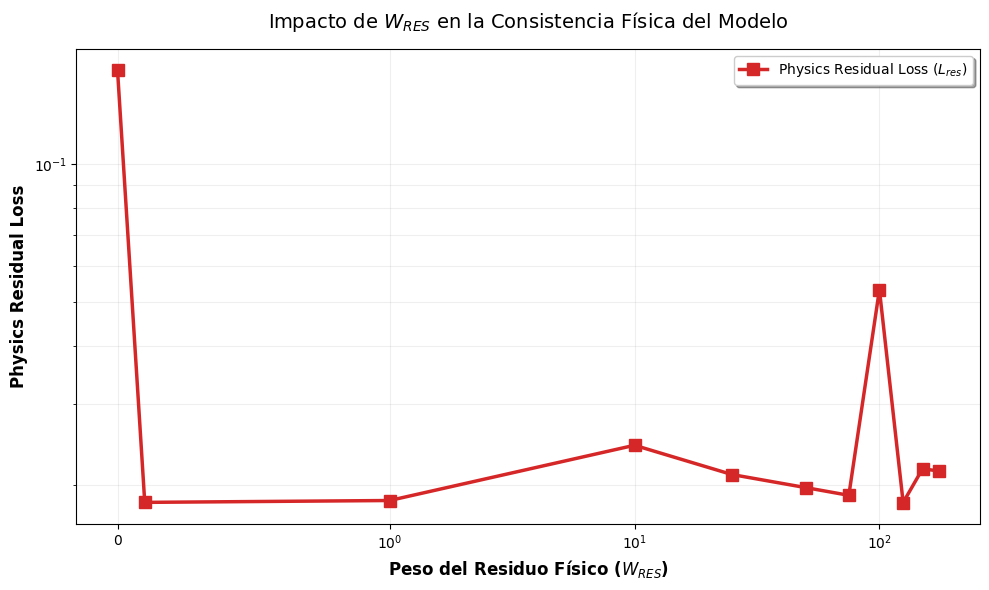

In [ ]:
import matplotlib.pyplot as plt

# Usamos el dataframe con el barrido completo
df_plot = df_sens_fine

fig, ax = plt.subplots(figsize=(10, 6))

# Graficar únicamente la pérdida física vs W_RES
ax.plot(df_plot['W_RES'], df_plot['L_Res'],
        marker='s', ls='-', color='#d62728',
        linewidth=2.5, markersize=8, label='Physics Residual Loss ($L_{res}$)')

# Configuración de ejes
ax.set_xlabel('Peso del Residuo Físico ($W_{RES}$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Physics Residual Loss', fontsize=12, fontweight='bold')
ax.set_title('Impacto de $W_{RES}$ en la Consistencia Física del Modelo', fontsize=14, pad=15)

# Escala logarítmica para apreciar el comportamiento en valores bajos y altos de peso
ax.set_xscale('symlog', linthresh=1)
# Escala logarítmica en Y es recomendada para ver órdenes de magnitud de error
ax.set_yscale('log')

# Estética
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.legend(loc='upper right', frameon=True, shadow=True)

# Anotación del punto de saturación (ajusta según tus resultados si es necesario)
# Si en 300 o 350 es el mínimo real:
# ax.annotate('Máxima Consistencia', xy=(350, df_plot.loc[df_plot['W_RES']==350, 'L_Res'].values[0]),
#              xytext=(400, 1e-1), arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

In [ ]:
# --- ANÁLISIS DE SENSIBILIDAD PARA EL PESO DE CONDICIÓN INICIAL (W_IC) ---
w_ic_sweep = [0.1, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0]
results_ic = []
NUM_EPOCHS_SENS = 3000

# Valores fijos basados en los análisis anteriores
W_DATA_FIXED = 1.0
W_RES_FIXED = 100.0

print(f"{'='*80}")
print(f"{'BÚSQUEDA DE LA IMPORTANCIA ÓPTIMA DE CI (W_IC)':^80}")
print(f"{'='*80}")

for w_ic_val in w_ic_sweep:
    print(f"\n>>> Evaluando: W_IC = {w_ic_val}")

    model_s = PINN_StateSpace_SiLU(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_LAYERS, HIDDEN_NEURONS).to(device)
    optimizer = optim.Adam(model_s.parameters(), lr=1e-3)

    for epoch in range(1, NUM_EPOCHS_SENS + 1):
        optimizer.zero_grad()
        total_loss, l_data, l_res, l_ic = calculate_total_loss(
            model_s, physics_loss_module,
            X_train_tensor, Y_train_tensor, X_physics_tensor,
            w_data=W_DATA_FIXED, w_res=W_RES_FIXED, w_ic=w_ic_val
        )
        total_loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"  [Epoch {epoch:>4}] | L_Total: {total_loss.item():.3e} | L_IC: {l_ic.item():.3e} | L_Phys: {l_res.item():.3e}")

    results_ic.append({
        'W_IC': w_ic_val,
        'L_IC': l_ic.item(),
        'L_Data': l_data.item(),
        'L_Res': l_res.item(),
        'Total_Weighted': total_loss.item()
    })

df_sens_ic = pd.DataFrame(results_ic)

print(f"\n{'='*80}")
print(f"{'RESULTADOS FINALES DESGLOSADOS (SWEEP W_IC)':^80}")
print(df_sens_ic.to_string(index=False))
print(f"{'='*80}")

                 BÚSQUEDA DE LA IMPORTANCIA ÓPTIMA DE CI (W_IC)                 

>>> Evaluando: W_IC = 0.1
  [Epoch  500] | L_Total: 6.489e+01 | L_IC: 1.628e-04 | L_Phys: 6.489e-01
  [Epoch 1000] | L_Total: 1.159e+01 | L_IC: 2.159e-04 | L_Phys: 1.159e-01
  [Epoch 1500] | L_Total: 4.776e+00 | L_IC: 1.642e-04 | L_Phys: 4.776e-02
  [Epoch 2000] | L_Total: 2.889e+00 | L_IC: 1.435e-04 | L_Phys: 2.889e-02
  [Epoch 2500] | L_Total: 2.108e+00 | L_IC: 1.538e-04 | L_Phys: 2.108e-02
  [Epoch 3000] | L_Total: 1.736e+00 | L_IC: 1.600e-04 | L_Phys: 1.736e-02

>>> Evaluando: W_IC = 1.0
  [Epoch  500] | L_Total: 6.804e+01 | L_IC: 1.511e-04 | L_Phys: 6.804e-01
  [Epoch 1000] | L_Total: 5.244e+01 | L_IC: 2.128e-04 | L_Phys: 5.244e-01
  [Epoch 1500] | L_Total: 6.754e+00 | L_IC: 1.858e-04 | L_Phys: 6.753e-02
  [Epoch 2000] | L_Total: 2.728e+00 | L_IC: 1.622e-04 | L_Phys: 2.727e-02
  [Epoch 2500] | L_Total: 1.880e+00 | L_IC: 1.711e-04 | L_Phys: 1.879e-02
  [Epoch 3000] | L_Total: 1.541e+00 | L_IC: 1.648e-

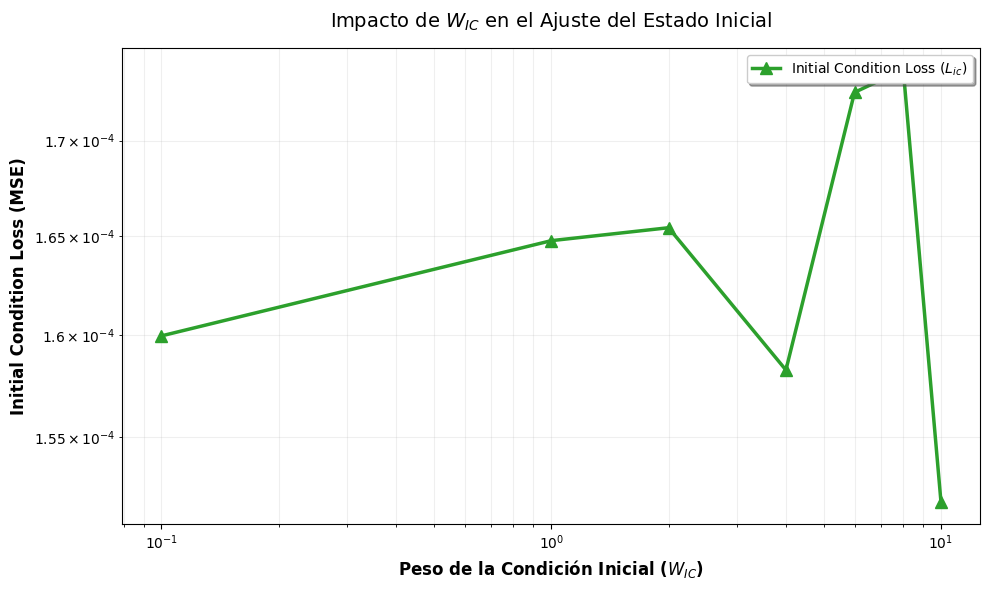

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_sens_ic

fig, ax = plt.subplots(figsize=(10, 6))

# Graficar únicamente la pérdida de condición inicial vs W_IC
ax.plot(df_plot['W_IC'], df_plot['L_IC'],
        marker='^', ls='-', color='#2ca02c', # Verde para diferenciar de Data y Phys
        linewidth=2.5, markersize=8, label='Initial Condition Loss ($L_{ic}$)')

ax.set_xlabel('Peso de la Condición Inicial ($W_{IC}$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Initial Condition Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Impacto de $W_{IC}$ en el Ajuste del Estado Inicial', fontsize=14, pad=15)

# Escalas logarítmicas para ver la caída de órdenes de magnitud
ax.set_xscale('log')
ax.set_yscale('log')

ax.grid(True, which="both", ls="-", alpha=0.2)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()